In [19]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
import os
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
import time
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix, ConfusionMatrixDisplay, precision_score
from pyspark.sql.functions import col

# **PySpark**

In [20]:
# 1. Crear una SparkSession
spark = SparkSession.builder \
    .appName("MiApp") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [ ]:
df_spark = spark.read.csv("data/df_final.csv", header=True, inferSchema=True)
df_spark.show(5)

+-----------+----------+---------+----------+--------------+----------+-------------------+--------+------------------+-----+-----------+----------------+--------------+--------------------------+----------------+--------------+------------+----------------+-----------+--------------+------------------------+-----------+---------------------+--------------+--------+--------------------+---------------------+---------------------+---------+----------------+------------+------------------+------------------+--------------------+---------+-----------------+-------+
|funded_amnt|      term|sub_grade|emp_length|home_ownership|annual_inc|verification_status| issue_d|           purpose|  dti|delinq_2yrs|earliest_cr_line|inq_last_6mths|collections_12_mths_ex_med|application_type|acc_now_delinq|tot_coll_amt|total_rev_hi_lim|avg_cur_bal|bc_open_to_buy|chargeoff_within_12_mths|delinq_amnt|mo_sin_rcnt_rev_tl_op|mo_sin_rcnt_tl|mort_acc|mths_since_recent_bc|mths_since_recent_inq|num_accts_ever_120_p

In [22]:
# Definir las columnas
categorical_cols = [
    'term',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type'
]

numerical_cols = [
    'funded_amnt',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'collections_12_mths_ex_med',
    'acc_now_delinq',
    'tot_coll_amt',
    'total_rev_hi_lim',
    'avg_cur_bal',
    'bc_open_to_buy',
    'chargeoff_within_12_mths',
    'delinq_amnt',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'mort_acc',
    'mths_since_recent_bc',
    'mths_since_recent_inq',
    'num_accts_ever_120_pd',
    'num_il_tl',
    'num_tl_120dpd_2m',
    'num_tl_30dpd',
    'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m',
    'pub_rec_bankruptcies',
    'tax_liens',
    'total_bal_ex_mort'
]

label_col = "default"

## *Pipeline de Transformación de Features*

In [23]:
# 3. Pipeline de transformación
indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_index") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=f"{col}_index", outputCol=f"{col}_encoded") for col in categorical_cols]

# Ensamblar numéricas
assembler_num = VectorAssembler(inputCols=numerical_cols, outputCol="num_features")
scaler = StandardScaler(inputCol="num_features", outputCol="scaled_features")

# Ensamblar todas las features
assembler_all = VectorAssembler(
    inputCols=["scaled_features"] + [f"{col}_encoded" for col in categorical_cols],
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + encoders + [assembler_num, scaler, assembler_all])


In [24]:
# 4. Transformar los datos
pipeline_model = pipeline.fit(df_spark)
df_transformed = pipeline_model.transform(df_spark)

# *División del dataset*

Aquí usamos sampleBy para realizar una división estratificada de los datos, asegurando que cada clase de la variable objetivo esté representada de forma proporcional tanto en el conjunto de entrenamiento como en el de prueba.

In [ ]:
 # 5. División estratificada train/test

# Obtener las clases únicas
classes = df_transformed.select(label_col).distinct().rdd.flatMap(lambda x: x).collect()

# Definir fracción 0.7 para cada clase
fractions = {c: 0.7 for c in classes}

# Sample estratificado
train_df = df_transformed.sampleBy(label_col, fractions, seed=42)
test_df = df_transformed.subtract(train_df)

print("Train size:", train_df.count(), "Test size:", test_df.count())

Train size: 942296 Test size: 403014


In [26]:
from pyspark.sql import functions as F

def check_distribution(df, label_col, name="dataset"):
    dist = df.groupBy(label_col).count()
    total = df.count()
    dist = dist.withColumn("proportion", F.col("count") / total)
    print(f"Distribución en {name}:")
    dist.show()

# Revisar
check_distribution(df_transformed, label_col, "original")
check_distribution(train_df, label_col, "train")
check_distribution(test_df, label_col, "test")


Distribución en original:


+-------+-------+-------------------+
|default|  count|         proportion|
+-------+-------+-------------------+
|    0.0|1076751| 0.8003738915194267|
|    1.0| 268559|0.19962610848057324|
+-------+-------+-------------------+



Distribución en train:


+-------+------+-------------------+
|default| count|         proportion|
+-------+------+-------------------+
|    0.0|753949| 0.8001190708652058|
|    1.0|188347|0.19988092913479416|
+-------+------+-------------------+



Distribución en test:


+-------+------+-------------------+
|default| count|         proportion|
+-------+------+-------------------+
|    0.0|322802| 0.8009696933605284|
|    1.0| 80212|0.19903030663947158|
+-------+------+-------------------+



## *Oversampling*

Para abordar el desbalance de clases y evitar que el modelo aprenda patrones principalmente de la clase mayoritaria, usamos oversampling. Es decir, duplicamos la clase minoritaria para que tenga un número de registros similar a la clase mayoritaria

In [ ]:
# Contar cuántos registros hay en cada clase
clase_counts = train_df.groupBy(label_col).count().collect()
clase_mayoritaria = max(clase_counts, key=lambda x: x["count"])["default"]
clase_menoritaria = min(clase_counts, key=lambda x: x["count"])["default"]
mayor_count = max(clase_counts, key=lambda x: x["count"])["count"]
menor_count = min(clase_counts, key=lambda x: x["count"])["count"]

print(f"Antes del balanceo -> Mayoritaria: {mayor_count} | Minoritaria: {menor_count}")

df_mayoritaria = train_df.filter(col(label_col) == clase_mayoritaria)
df_menoritaria = train_df.filter(col(label_col) == clase_menoritaria)

# Calcular factor de oversampling
factor = int(mayor_count / menor_count)

# Repetir la clase minoritaria
df_menor_oversampled = df_menoritaria
for _ in range(factor - 1):
    df_menor_oversampled = df_menor_oversampled.union(df_menoritaria)

# Dataset balanceado final
train_df = df_mayoritaria.union(df_menor_oversampled)

print("Después del balanceo:")
train_df.groupBy(label_col).count().show()

Antes del balanceo -> Mayoritaria: 753949 | Minoritaria: 188347
Después del balanceo:


+-------+------+
|default| count|
+-------+------+
|    0.0|753949|
|    1.0|753388|
+-------+------+



## *Modelado*


Entrenando modelo con layers=[93, 10, 2], stepSize=0.1, maxIter=100



Entrenando modelo con layers=[93, 10, 2], stepSize=0.1, maxIter=200



Entrenando modelo con layers=[93, 10, 2], stepSize=0.01, maxIter=100



Entrenando modelo con layers=[93, 10, 2], stepSize=0.01, maxIter=200



Entrenando modelo con layers=[93, 10, 2], stepSize=0.001, maxIter=100


...


Entrenando modelo con layers=[93, 100, 2], stepSize=0.01, maxIter=100



Entrenando modelo con layers=[93, 100, 2], stepSize=0.01, maxIter=200



Entrenando modelo con layers=[93, 100, 2], stepSize=0.001, maxIter=100



Entrenando modelo con layers=[93, 100, 2], stepSize=0.001, maxIter=200



===== Mejor modelo (según Recall) =====
Layers: [93, 50, 2], StepSize: 0.001, MaxIter: 100
AUC: 0.7078 | Accuracy: 0.6416 | F1: 0.6772 | Recall: 0.6834
Train time: 83.47s | Pred time: 0.01s


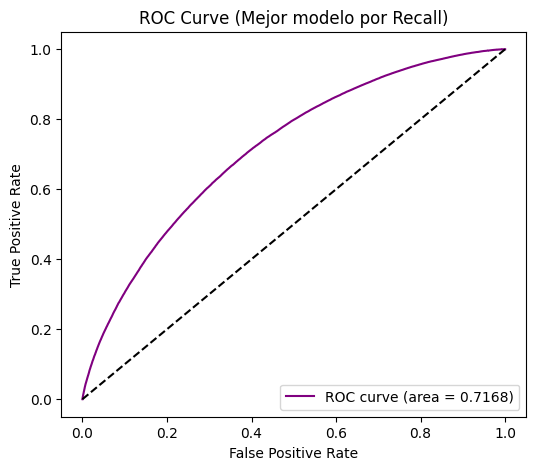

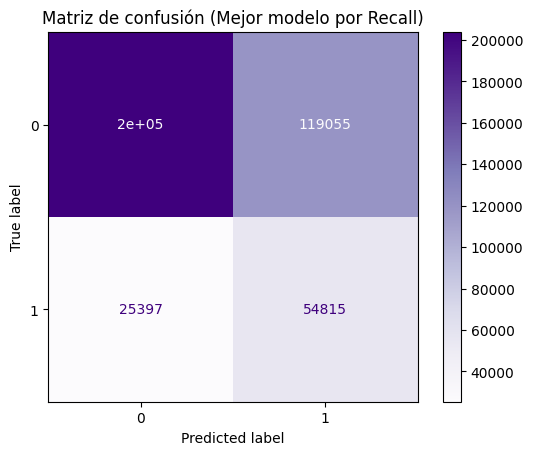

In [15]:
num_features = len(df_transformed.select("features").first()[0])

layers_list = [
    [num_features, 10, 2],
    [num_features, 50, 2],
    [num_features, 100, 2]
]
step_sizes = [0.1, 0.01, 0.001]
max_iters = [100, 200]

binary_eval = BinaryClassificationEvaluator(labelCol="default", metricName="areaUnderROC")
accuracy_eval = MulticlassClassificationEvaluator(labelCol="default", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="default", metricName="f1")
recall_eval = MulticlassClassificationEvaluator(labelCol="default", predictionCol="prediction",
                                                metricName="recallByLabel", metricLabel=1)

# ========================================
# 3. Entrenamiento y evaluación de modelos
# ========================================
results = []

for layers in layers_list:
    for step in step_sizes:
        for iters in max_iters:
            print(f"\nEntrenando modelo con layers={layers}, stepSize={step}, maxIter={iters}")

            # Instanciar modelo MLP
            mlp = MultilayerPerceptronClassifier(
                featuresCol="features",
                labelCol="default",
                layers=layers,
                blockSize=128,
                seed=42,
                maxIter=iters,
                stepSize=step
            )

            # Tiempo de entrenamiento
            start_time = time.time()
            model = mlp.fit(train_df)
            train_time = time.time() - start_time

            # Tiempo de predicción
            start_time = time.time()
            predictions = model.transform(test_df)
            pred_time = time.time() - start_time

            # Métricas
            auc = binary_eval.evaluate(predictions)
            acc = accuracy_eval.evaluate(predictions)
            f1 = f1_eval.evaluate(predictions)
            recall = recall_eval.evaluate(predictions)

            results.append({
                "layers": layers,
                "stepSize": step,
                "maxIter": iters,
                "AUC": auc,
                "Accuracy": acc,
                "F1": f1,
                "Recall": recall,
                "train_time": train_time,
                "pred_time": pred_time,
                "model": model,
                "predictions": predictions
            })

# ========================================
# 4. Selección del mejor modelo por Recall
# ========================================
best_result = max(results, key=lambda x: x["Recall"])
best_model = best_result["model"]
best_preds = best_result["predictions"]

print("\n===== Mejor modelo (según Recall) =====")
print(f"Layers: {best_result['layers']}, StepSize: {best_result['stepSize']}, MaxIter: {best_result['maxIter']}")
print(f"AUC: {best_result['AUC']:.4f} | Accuracy: {best_result['Accuracy']:.4f} | "
      f"F1: {best_result['F1']:.4f} | Recall: {best_result['Recall']:.4f}")
print(f"Train time: {best_result['train_time']:.2f}s | Pred time: {best_result['pred_time']:.2f}s")

# ========================================
# 5. Gráficos del mejor modelo
# ========================================
# --- ROC Curve ---
y_true = [row["default"] for row in best_preds.select("default").collect()]
y_score = [float(row["probability"][1]) for row in best_preds.select("probability").collect()]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.4f})", color="purple")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Mejor modelo por Recall)")
plt.legend(loc="lower right")
plt.show()

# --- Matriz de confusión ---
y_pred = [int(row["prediction"]) for row in best_preds.select("prediction").collect()]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Purples")
plt.title("Matriz de confusión (Mejor modelo por Recall)")
plt.show()